In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [3]:
# Generate a date range for one year with hourly frequency
date_rng = pd.date_range(start="1/1/2020", end="1/1/2022", freq="H")

# Generate random PM2.5 values
np.random.seed(42)
pm25_values = np.random.rand(len(date_rng)) * 100  # PM2.5 values between 0 and 100

# Create a DataFrame
data = pd.DataFrame(date_rng, columns=["date"])
data["PM2.5"] = pm25_values
data = data.set_index("date")

# Display the first few rows
print(data.head())


                         PM2.5
date                          
2020-01-01 00:00:00  37.454012
2020-01-01 01:00:00  95.071431
2020-01-01 02:00:00  73.199394
2020-01-01 03:00:00  59.865848
2020-01-01 04:00:00  15.601864


C:\Users\13993807_admin\AppData\Local\Temp\ipykernel_23204\1100594315.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_rng = pd.date_range(start="1/1/2020", end="1/1/2022", freq="H")


## SARIMA


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Split data into train and test sets
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# SARIMA Model
sarima_model = SARIMAX(train["PM2.5"], order=(2, 1, 2), seasonal_order=(1, 1, 1, 24))
sarima_fit = sarima_model.fit(disp=False)

# Forecast for 3-hour and 6-hour intervals
sarima_forecast_3h = sarima_fit.forecast(steps=3)
sarima_forecast_6h = sarima_fit.forecast(steps=6)


# Evaluate SARIMA model
def evaluate_forecast(true, predicted):
    rmse = np.sqrt(mean_squared_error(true[: len(predicted)], predicted))
    mae = mean_absolute_error(true[: len(predicted)], predicted)
    return rmse, mae


sarima_rmse_3h, sarima_mae_3h = evaluate_forecast(test["PM2.5"], sarima_forecast_3h)
sarima_rmse_6h, sarima_mae_6h = evaluate_forecast(test["PM2.5"], sarima_forecast_6h)

print(f"SARIMA 3-hour RMSE: {sarima_rmse_3h}, MAE: {sarima_mae_3h}")
print(f"SARIMA 6-hour RMSE: {sarima_rmse_6h}, MAE: {sarima_mae_6h}")


## Random forest


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Prepare data for Random Forest model
train["hour"] = train.index.hour
test["hour"] = test.index.hour

rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(train[["hour"]], train["PM2.5"])

# Forecast for 3-hour and 6-hour intervals
rf_forecast_3h = rf_model.predict(test[["hour"]].iloc[:3])
rf_forecast_6h = rf_model.predict(test[["hour"]].iloc[:6])

# Evaluate Random Forest model
rf_rmse_3h, rf_mae_3h = evaluate_forecast(test["PM2.5"], rf_forecast_3h)
rf_rmse_6h, rf_mae_6h = evaluate_forecast(test["PM2.5"], rf_forecast_6h)

print(f"Random Forest 3-hour RMSE: {rf_rmse_3h}, MAE: {rf_mae_3h}")
print(f"Random Forest 6-hour RMSE: {rf_rmse_6h}, MAE: {rf_mae_6h}")


## LSTM


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


# Prepare data for LSTM model
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)


seq_length = 24  # Use 24 hours of data to predict the next value
X_train, y_train = create_sequences(train["PM2.5"].values, seq_length)
X_test, y_test = create_sequences(test["PM2.5"].values, seq_length)

# Reshape data for LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build LSTM model
lstm_model = Sequential(
    [LSTM(50, return_sequences=True, input_shape=(seq_length, 1)), LSTM(50), Dense(1)]
)
lstm_model.compile(optimizer="adam", loss="mse")

# Train LSTM model
lstm_model.fit(X_train, y_train, epochs=10, batch_size=32)

# Forecast for 3-hour and 6-hour intervals
lstm_forecast_3h = lstm_model.predict(X_test[:3])
lstm_forecast_6h = lstm_model.predict(X_test[:6])

# Evaluate LSTM model
lstm_rmse_3h, lstm_mae_3h = evaluate_forecast(y_test, lstm_forecast_3h)
lstm_rmse_6h, lstm_mae_6h = evaluate_forecast(y_test, lstm_forecast_6h)

print(f"LSTM 3-hour RMSE: {lstm_rmse_3h}, MAE: {lstm_mae_3h}")
print(f"LSTM 6-hour RMSE: {lstm_rmse_6h}, MAE: {lstm_mae_6h}")


In [ ]:
# Print comparison results
print(f"Comparison of Models for 3-hour Forecast:")
print(f"SARIMA 3-hour RMSE: {sarima_rmse_3h}, MAE: {sarima_mae_3h}")
print(f"Random Forest 3-hour RMSE: {rf_rmse_3h}, MAE: {rf_mae_3h}")
print(f"LSTM 3-hour RMSE: {lstm_rmse_3h}, MAE: {lstm_mae_3h}")

print(f"\nComparison of Models for 6-hour Forecast:")
print(f"SARIMA 6-hour RMSE: {sarima_rmse_6h}, MAE: {sarima_mae_6h}")
print(f"Random Forest 6-hour RMSE: {rf_rmse_6h}, MAE: {rf_mae_6h}")
print(f"LSTM 6-hour RMSE: {lstm_rmse_6h}, MAE: {lstm_mae_6h}")


C:\Users\13993807_admin\AppData\Roaming\Python\Python39\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\13993807_admin\AppData\Roaming\Python\Python39\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Epoch 1/10
438/438 [==============================] - 39s 73ms/step - loss: 1802.7842
Epoch 2/10
438/438 [==============================] - 28s 64ms/step - loss: 1033.9558
Epoch 3/10
438/438 [==============================] - 25s 58ms/step - loss: 859.4056
Epoch 4/10
438/438 [==============================] - 22s 50ms/step - loss: 834.8311
Epoch 5/10
438/438 [==============================] - 13s 29ms/step - loss: 833.3951
Epoch 6/10
438/438 [==============================] - 11s 26ms/step - loss: 833.3471
Epoch 7/10
438/438 [==============================] - 11s 24ms/step - loss: 833.3471
Epoch 8/10
438/438 [==============================] - 10s 23ms/step - loss: 833.4348
Epoch 9/10
438/438 [==============================] - 10s 24ms/step - loss: 833.3878
Epoch 10/10
109/109 [==============================] - 3s 9ms/step
SARIMA RMSE: 28.825235260900335, MAE: 24.815356368778787
Random Forest RMSE: 32.885604102361434, MAE: 27.32023116631978
LSTM RMSE: 28.797940286961754, MAE: 24.8153643

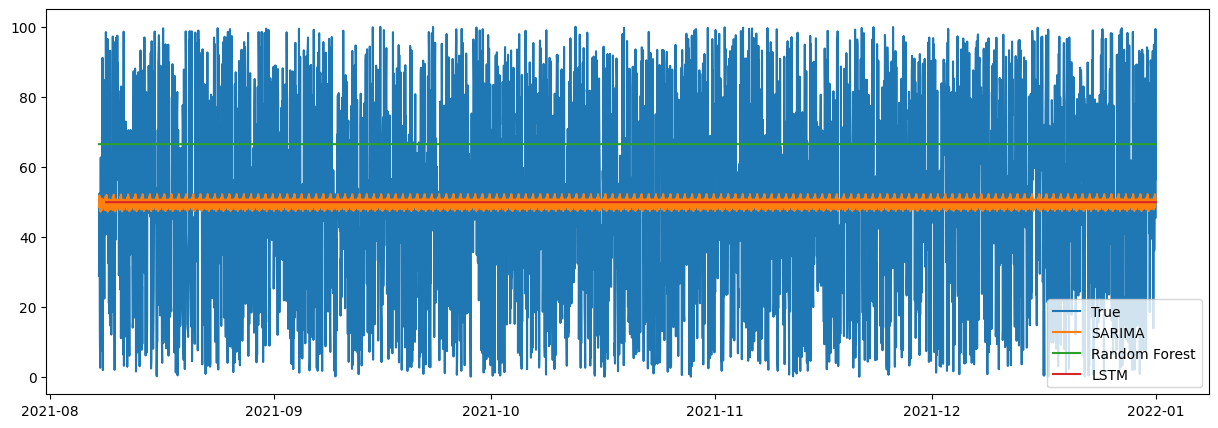

In [4]:
# # Split data
# train_size = int(len(data) * 0.8)
# train, test = data[:train_size], data[train_size:]

# # SARIMA Model
# sarima_model = SARIMAX(train["PM2.5"], order=(2, 1, 2), seasonal_order=(1, 1, 1, 24))
# sarima_fit = sarima_model.fit(disp=False)
# sarima_forecast = sarima_fit.forecast(steps=len(test))

# # Random Forest Model
# rf_model = RandomForestRegressor(n_estimators=100)
# rf_model.fit(np.arange(len(train)).reshape(-1, 1), train["PM2.5"])
# rf_forecast = rf_model.predict(
#     np.arange(len(train), len(train) + len(test)).reshape(-1, 1)
# )


# # LSTM Model
# def create_sequences(data, seq_length):
#     X, y = [], []
#     for i in range(len(data) - seq_length):
#         X.append(data[i : i + seq_length])
#         y.append(data[i + seq_length])
#     return np.array(X), np.array(y)


# seq_length = 24
# X_train, y_train = create_sequences(train["PM2.5"].values, seq_length)
# X_test, y_test = create_sequences(test["PM2.5"].values, seq_length)

# lstm_model = Sequential(
#     [LSTM(50, return_sequences=True, input_shape=(seq_length, 1)), LSTM(50), Dense(1)]
# )
# lstm_model.compile(optimizer="adam", loss="mse")
# lstm_model.fit(X_train, y_train, epochs=10, batch_size=32)

# lstm_forecast = lstm_model.predict(X_test)


# # Evaluate Models
# def evaluate_forecast(true, predicted):
#     rmse = np.sqrt(mean_squared_error(true, predicted))
#     mae = mean_absolute_error(true, predicted)
#     return rmse, mae


# sarima_rmse, sarima_mae = evaluate_forecast(test["PM2.5"], sarima_forecast)
# rf_rmse, rf_mae = evaluate_forecast(test["PM2.5"], rf_forecast)
# lstm_rmse, lstm_mae = evaluate_forecast(y_test, lstm_forecast)

# # Compare Results
# print(f"SARIMA RMSE: {sarima_rmse}, MAE: {sarima_mae}")
# print(f"Random Forest RMSE: {rf_rmse}, MAE: {rf_mae}")
# print(f"LSTM RMSE: {lstm_rmse}, MAE: {lstm_mae}")

# # Plot Results
# plt.figure(figsize=(15, 5))
# plt.plot(test.index, test["PM2.5"], label="True")
# plt.plot(test.index, sarima_forecast, label="SARIMA")
# plt.plot(test.index, rf_forecast, label="Random Forest")
# plt.plot(test.index[-len(lstm_forecast) :], lstm_forecast, label="LSTM")
# plt.legend()
# plt.show()
